# Trading Simulation: Can Our Models Beat the Market?

This notebook backtests a simple value-betting strategy on the test split.

**Polymarket token economics**  
A YES token costs `price_at_snapshot` and pays $1 if the market resolves YES, $0 otherwise.  
A NO token costs `1 - price_at_snapshot` and pays $1 if the market resolves NO.

**Strategy**  
For each snapshot, compare the model's P(YES) to the current market price:
- `model_prob > market_price + edge`: buy YES → profit = `outcome - market_price`
- `model_prob < market_price - edge`: buy NO → profit = `(1 - outcome) - (1 - market_price)` = `market_price - outcome`
- Otherwise: no trade (0 profit)

**Baseline**  
The market-price baseline (AUC 0.964) essentially *is* the market — it never disagrees with itself, so it never trades and earns 0.  
A naïve always-buy-YES strategy earns `mean(outcome) - mean(market_price)` ≈ 0 on an efficient market.

We report **total P&L** and **ROI** (P&L / capital deployed) per model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

DATA_DIR   = '../data/'
MODELS_DIR = '../models/'

# Minimum edge (model_prob vs market_price) required to place a trade
MIN_EDGE = 0.02

## 1. Load Data

In [2]:
# Load only the columns we need from the clean dataset (test split)
cols = ['market_id', 'snapshot_timestamp', 'price_at_snapshot', 'outcome',
        'split', 'category', 'days_before_close', 'duration_days']

df_full = pd.read_parquet(DATA_DIR + 'polymarket_ml_dataset_clean.parquet', columns=cols)
df = df_full[df_full['split'] == 'test'].copy().reset_index(drop=True)

# Normalize timestamp timezone for merging
df['snapshot_timestamp'] = pd.to_datetime(df['snapshot_timestamp'], utc=True)

print(f"Test snapshots: {len(df):,}")
print(f"Unique markets:  {df['market_id'].nunique():,}")
print(f"Outcome balance: {df['outcome'].mean():.1%} YES")
df.head(3)

Test snapshots: 288,490
Unique markets:  4,174
Outcome balance: 21.0% YES


,market_id,snapshot_timestamp,price_at_snapshot,outcome,split,category,days_before_close,duration_days
0,0xdbdc9d6ae20cd847d8b7728de6ce7a788dfccadde77a...,2025-09-13 21:57:39.995020+00:00,0.180,1,test,crypto,109.25,123
1,0xdbdc9d6ae20cd847d8b7728de6ce7a788dfccadde77a...,2025-09-14 09:57:39.995020+00:00,0.195,1,test,crypto,108.75,123
2,0xdbdc9d6ae20cd847d8b7728de6ce7a788dfccadde77a...,2025-09-14 21:57:39.995020+00:00,0.185,1,test,crypto,108.25,123


In [3]:
# Load model predictions
lr = pd.read_csv(MODELS_DIR + 'logistic_regression/predictions/predictions.csv',
                 parse_dates=['snapshot_timestamp'])
lr['snapshot_timestamp'] = pd.to_datetime(lr['snapshot_timestamp'], utc=True)

rf_base = pd.read_csv(MODELS_DIR + 'random_forest/predictions/test_predictions.csv',
                      parse_dates=['snapshot_timestamp'])
rf_base['snapshot_timestamp'] = pd.to_datetime(rf_base['snapshot_timestamp'], utc=True)

rf = pd.read_csv(MODELS_DIR + 'random_forest_trends/predictions/trends_test_predictions.csv',
                 parse_dates=['snapshot_timestamp'])
rf['snapshot_timestamp'] = pd.to_datetime(rf['snapshot_timestamp'], utc=True)

gb = pd.read_csv(MODELS_DIR + 'gradient_boosting/predictions/predictions.csv',
                 parse_dates=['snapshot_timestamp'])
gb['snapshot_timestamp'] = pd.to_datetime(gb['snapshot_timestamp'], utc=True)

print('LR columns:       ', lr.columns.tolist())
print('RF base columns:  ', rf_base.columns.tolist())
print('RF trends columns:', rf.columns.tolist())
print('GB columns:       ', gb.columns.tolist())

LR columns:        ['market_id', 'snapshot_timestamp', 'category', 'outcome', 'pred_prob_base', 'pred_prob_trends', 'pred_label_base', 'pred_label_trends']
RF base columns:   ['market_id', 'snapshot_timestamp', 'outcome', 'split', 'proba_price_only', 'proba_full', 'proba_full_calibrated']
RF trends columns: ['market_id', 'snapshot_timestamp', 'outcome', 'split', 'proba_price_only', 'proba_full', 'proba_trends', 'proba_trends_calibrated']
GB columns:        ['market_id', 'snapshot_timestamp', 'category', 'outcome', 'pred_prob_base', 'pred_prob_trends', 'pred_label_base', 'pred_label_trends']


## 2. Merge Predictions with Market Prices

All three models include `snapshot_timestamp` — join all on `(market_id, snapshot_timestamp)`.

In [4]:
key = ['market_id', 'snapshot_timestamp']
price_cols = key + ['price_at_snapshot', 'days_before_close', 'duration_days']

lr_merged      = lr.merge(df[price_cols], on=key, how='left')
rf_base_merged = rf_base.merge(df[price_cols + ['category']], on=key, how='left')
rf_merged      = rf.merge(df[price_cols + ['category']], on=key, how='left')
gb_merged      = gb.merge(df[price_cols], on=key, how='left')

print(f"LR merged rows:        {len(lr_merged):,}  (NaN prices: {lr_merged['price_at_snapshot'].isna().sum():,})")
print(f"RF base merged rows:   {len(rf_base_merged):,}  (NaN prices: {rf_base_merged['price_at_snapshot'].isna().sum():,})")
print(f"RF trends merged rows: {len(rf_merged):,}  (NaN prices: {rf_merged['price_at_snapshot'].isna().sum():,})")
print(f"GB merged rows:        {len(gb_merged):,}  (NaN prices: {gb_merged['price_at_snapshot'].isna().sum():,})")

LR merged rows:        288,490  (NaN prices: 0)
RF base merged rows:   288,490  (NaN prices: 0)
RF trends merged rows: 288,490  (NaN prices: 0)
GB merged rows:        288,490  (NaN prices: 0)


## 3. Trading Strategy Helper

In [5]:
def simulate_trades(model_prob, market_price, outcome, min_edge=MIN_EDGE):
    edge = model_prob - market_price
    pnl = np.zeros(len(model_prob))

    buy_yes = edge > min_edge
    buy_no  = edge < -min_edge

    pnl[buy_yes] = outcome[buy_yes] - market_price[buy_yes]
    pnl[buy_no]  = market_price[buy_no] - outcome[buy_no]

    return pd.Series(pnl)


def trading_summary(pnl_series, market_price_series, model_name):
    pnl    = pnl_series.values
    prices = market_price_series.values
    traded    = pnl != 0
    n_trades  = traded.sum()
    total_pnl = pnl.sum()
    capital   = prices[traded].sum()
    roi       = total_pnl / capital if capital > 0 else np.nan
    win_rate  = (pnl[traded] > 0).mean() if n_trades > 0 else np.nan

    return {
        'model':      model_name,
        'n_trades':   int(n_trades),
        'total_pnl':  round(total_pnl, 2),
        'roi_%':      round(roi * 100, 2) if not np.isnan(roi) else np.nan,
        'win_rate_%': round(win_rate * 100, 2) if not np.isnan(win_rate) else np.nan,
    }


def get_horizon_snapshot(merged_df, prob_col, horizon_days, tolerance=2.0):
    """
    For each market, pick the snapshot closest to `horizon_days` after market open.
    days_after_open = duration_days - days_before_close
    Returns one row per market at a real observed price.
    Markets with no snapshot within `tolerance` days of the horizon are dropped.
    """
    tmp = merged_df.dropna(subset=['price_at_snapshot', 'duration_days', 'days_before_close']).copy()
    tmp['days_after_open'] = tmp['duration_days'] - tmp['days_before_close']
    tmp['dist'] = (tmp['days_after_open'] - horizon_days).abs()
    closest = tmp.loc[tmp.groupby('market_id')['dist'].idxmin()]
    closest = closest[closest['dist'] <= tolerance]
    return closest[['market_id', 'snapshot_timestamp', prob_col,
                     'price_at_snapshot', 'outcome', 'category']].rename(
        columns={prob_col: 'model_prob', 'price_at_snapshot': 'market_price'}
    ).reset_index(drop=True)

## 4. Per-Snapshot Simulation (LR, RF & GB)

Trade at every snapshot in the test set.

In [6]:
results = []
pnl_series = {}

# ----- Logistic Regression -----
sub = lr_merged.dropna(subset=['price_at_snapshot'])
for col, label in [('pred_prob_base', 'LR (base)'), ('pred_prob_trends', 'LR (trends)')]:
    pnl = simulate_trades(sub[col].values, sub['price_at_snapshot'].values, sub['outcome'].values)
    pnl_series[label] = pnl
    results.append(trading_summary(pnl, sub['price_at_snapshot'], label))

# ----- Random Forest -----
for sub, col, label in [
    (rf_base_merged.dropna(subset=['price_at_snapshot']), 'proba_full_calibrated',   'RF (base)'),
    (rf_merged.dropna(subset=['price_at_snapshot']),      'proba_trends_calibrated', 'RF (trends)'),
]:
    pnl = simulate_trades(sub[col].values, sub['price_at_snapshot'].values, sub['outcome'].values)
    pnl_series[label] = pnl
    results.append(trading_summary(pnl, sub['price_at_snapshot'], label))

# ----- Gradient Boosting -----
sub = gb_merged.dropna(subset=['price_at_snapshot'])
for col, label in [('pred_prob_base', 'GB (base)'), ('pred_prob_trends', 'GB (trends)')]:
    pnl = simulate_trades(sub[col].values, sub['price_at_snapshot'].values, sub['outcome'].values)
    pnl_series[label] = pnl
    results.append(trading_summary(pnl, sub['price_at_snapshot'], label))

summary_df = pd.DataFrame(results)
print('Per-snapshot trading results (min_edge={:.2f})'.format(MIN_EDGE))
summary_df

Per-snapshot trading results (min_edge=0.02)


,model,n_trades,total_pnl,roi_%,win_rate_%
0,LR (base),219973,10669.91,17.06,70.41
1,LR (trends),218328,10691.14,17.09,70.50
2,RF (base),199506,15047.09,25.09,73.80
3,RF (trends),204732,17003.99,26.63,71.59
4,GB (base),215490,16756.59,25.77,72.88
5,GB (trends),217570,18096.99,27.48,73.80


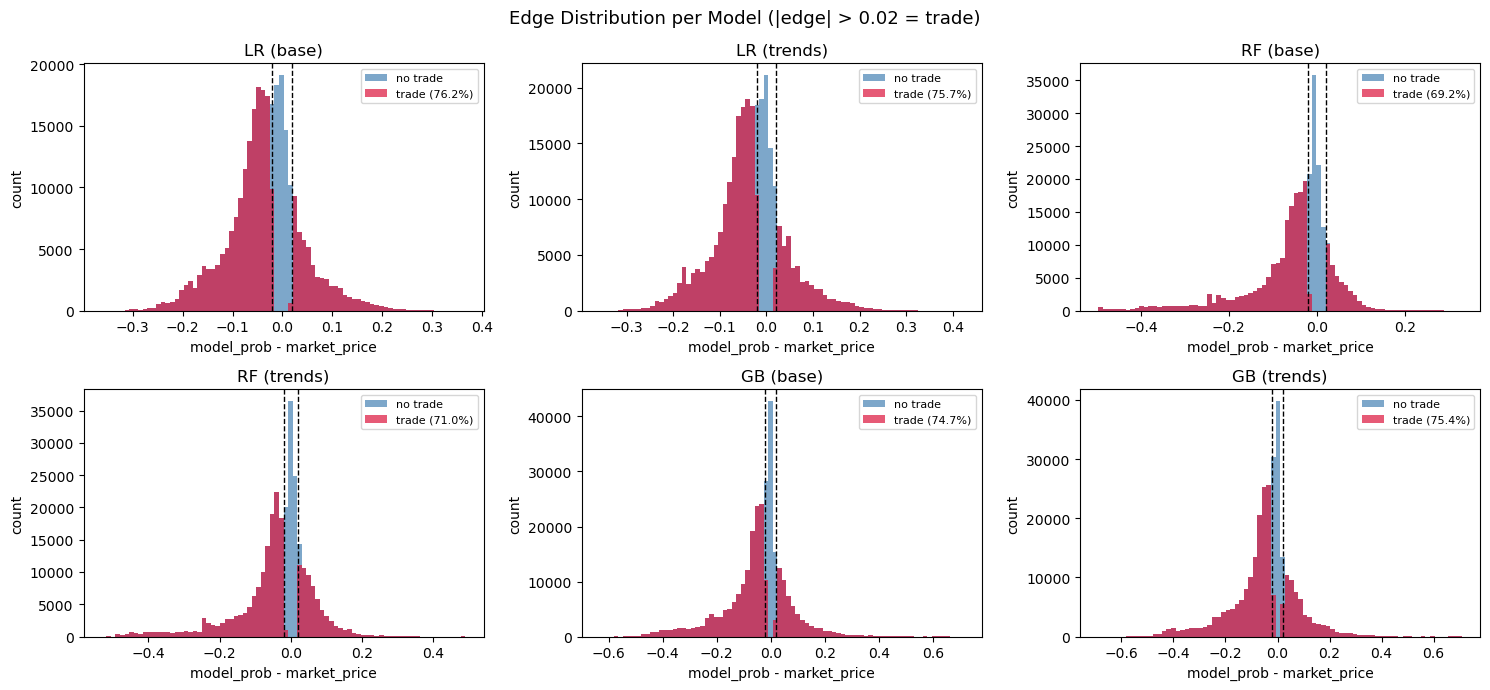

,model,n_snapshots,n_trades,pct_traded,edge_mean,edge_std,edge_abs_mean
0,LR (base),288490,219973,76.2,-0.0335,0.0739,0.0613
1,LR (trends),288490,218328,75.7,-0.0337,0.0745,0.0617
2,RF (base),288490,199506,69.2,-0.0493,0.0938,0.0669
3,RF (trends),288490,204732,71.0,-0.0371,0.1023,0.0700
4,GB (base),288490,215490,74.7,-0.0441,0.1192,0.0849
5,GB (trends),288490,217570,75.4,-0.0440,0.1186,0.0857


In [7]:
# --- Edge distribution diagnostic ---
edge_stats = []
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=False)
axes = axes.flatten()

model_series = [
    (lr_merged.dropna(subset=['price_at_snapshot']),      'pred_prob_base',         'LR (base)'),
    (lr_merged.dropna(subset=['price_at_snapshot']),      'pred_prob_trends',        'LR (trends)'),
    (rf_base_merged.dropna(subset=['price_at_snapshot']), 'proba_full_calibrated',   'RF (base)'),
    (rf_merged.dropna(subset=['price_at_snapshot']),      'proba_trends_calibrated', 'RF (trends)'),
    (gb_merged.dropna(subset=['price_at_snapshot']),      'pred_prob_base',          'GB (base)'),
    (gb_merged.dropna(subset=['price_at_snapshot']),      'pred_prob_trends',        'GB (trends)'),
]

for ax, (sub, col, label) in zip(axes, model_series):
    edge = sub[col].values - sub['price_at_snapshot'].values
    traded_mask = np.abs(edge) > MIN_EDGE
    pct_traded = traded_mask.mean() * 100

    ax.hist(edge, bins=80, color='steelblue', alpha=0.7, label='no trade')
    ax.hist(edge[traded_mask], bins=80, color='crimson', alpha=0.7, label=f'trade ({pct_traded:.1f}%)')
    ax.axvline( MIN_EDGE, color='black', linewidth=1, linestyle='--')
    ax.axvline(-MIN_EDGE, color='black', linewidth=1, linestyle='--')
    ax.set_title(label)
    ax.set_xlabel('model_prob - market_price')
    ax.set_ylabel('count')
    ax.legend(fontsize=8)

    edge_stats.append({
        'model':         label,
        'n_snapshots':   len(edge),
        'n_trades':      int(traded_mask.sum()),
        'pct_traded':    round(pct_traded, 1),
        'edge_mean':     round(edge.mean(), 4),
        'edge_std':      round(edge.std(), 4),
        'edge_abs_mean': round(np.abs(edge).mean(), 4),
    })

plt.suptitle(f'Edge Distribution per Model (|edge| > {MIN_EDGE} = trade)', fontsize=13)
plt.tight_layout()
plt.show()

pd.DataFrame(edge_stats)

## 5. Horizon-Based Simulation — One Real Trade Per Market

For each horizon N (days after market open), find the snapshot closest to N days for each market and trade at that real observed price. This gives exactly one trade per market per horizon — no price averaging, no double-counting.

In [8]:
print(f"Markets in test set: {df['market_id'].nunique():,}")

Markets in test set: 4,174


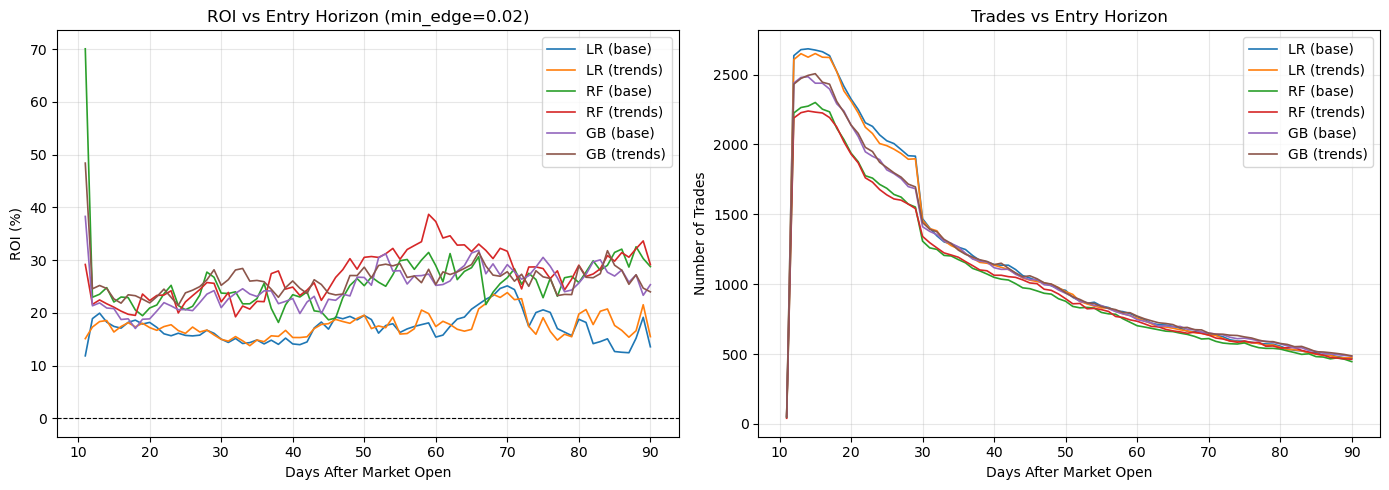

            roi_%                                                 n_trades  \
            count   mean   std    min    25%    50%    75%    max    count   
model                                                                        
GB (base)    80.0  24.92  3.78  17.02  22.00  24.87  27.35  38.26     80.0   
GB (trends)  80.0  26.28  3.36  21.40  24.41  26.18  27.76  48.37     80.0   
LR (base)    80.0  17.21  2.80  11.83  15.16  17.10  18.77  25.10     80.0   
LR (trends)  80.0  17.58  2.24  13.76  15.95  17.24  18.42  23.82     80.0   
RF (base)    80.0  25.77  6.11  18.16  22.84  25.30  27.89  70.04     80.0   
RF (trends)  80.0  27.24  4.55  19.23  23.34  27.68  30.71  38.66     80.0   

                                                                    
                mean     std   min     25%    50%      75%     max  
model                                                               
GB (base)    1106.68  611.33  53.0  641.75  893.0  1360.75  2484.0  
GB (trends)  1116.95 

In [9]:
HORIZONS = range(7, 91)  # days after market open to sweep

horizon_results = []
for h in HORIZONS:
    for merged_df, prob_col, label in [
        (lr_merged,      'pred_prob_base',         'LR (base)'),
        (lr_merged,      'pred_prob_trends',        'LR (trends)'),
        (rf_base_merged, 'proba_full_calibrated',   'RF (base)'),
        (rf_merged,      'proba_trends_calibrated', 'RF (trends)'),
        (gb_merged,      'pred_prob_base',          'GB (base)'),
        (gb_merged,      'pred_prob_trends',        'GB (trends)'),
    ]:
        snap = get_horizon_snapshot(merged_df, prob_col, h)
        if len(snap) == 0:
            continue
        pnl = simulate_trades(snap['model_prob'].values, snap['market_price'].values, snap['outcome'].values)
        traded = pnl != 0
        cap = snap['market_price'].values[traded.values].sum()
        roi = pnl.sum() / cap * 100 if cap > 0 else 0
        horizon_results.append({
            'horizon_days': h,
            'model':        label,
            'n_trades':     int(traded.sum()),
            'n_markets':    len(snap),
            'total_pnl':    round(pnl.sum(), 2),
            'roi_%':        round(roi, 2),
        })

horizon_df = pd.DataFrame(horizon_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for model in horizon_df['model'].unique():
    sub = horizon_df[horizon_df['model'] == model]
    ax1.plot(sub['horizon_days'], sub['roi_%'],   label=model, linewidth=1.2)
    ax2.plot(sub['horizon_days'], sub['n_trades'], label=model, linewidth=1.2)

ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xlabel('Days After Market Open')
ax1.set_ylabel('ROI (%)')
ax1.set_title(f'ROI vs Entry Horizon (min_edge={MIN_EDGE})')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.set_xlabel('Days After Market Open')
ax2.set_ylabel('Number of Trades')
ax2.set_title('Trades vs Entry Horizon')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('trading_roi_vs_horizon.png', dpi=150, bbox_inches='tight')
plt.show()

print(horizon_df.groupby('model')[['roi_%', 'n_trades']].describe().round(2))

## 6. Naïve Baselines

In [10]:
snap_naive = get_horizon_snapshot(lr_merged, 'pred_prob_base', horizon_days=30)
naive_pnl = snap_naive['outcome'] - snap_naive['market_price']
print("=== Naïve always-buy-YES (at 30 days after open) ===")
print(f"  Total P&L:  {naive_pnl.sum():.2f}")
print(f"  Mean P&L:   {naive_pnl.mean():.4f}  (should be ≈ 0 on an efficient market)")
print(f"  Capital:    {snap_naive['market_price'].sum():.2f}")
print(f"  ROI:        {naive_pnl.sum() / snap_naive['market_price'].sum() * 100:.2f}%")

print("\n=== Market-price baseline ===")
print("  Since the baseline model predicts market_price ≈ itself, edge = 0 → 0 trades → P&L = 0")

=== Naïve always-buy-YES (at 30 days after open) ===
  Total P&L:  -97.66
  Mean P&L:   -0.0518  (should be ≈ 0 on an efficient market)
  Capital:    505.66
  ROI:        -19.31%

=== Market-price baseline ===
  Since the baseline model predicts market_price ≈ itself, edge = 0 → 0 trades → P&L = 0


## 7. ROI by Min-Edge Threshold

How does ROI change as we require a larger edge before trading?

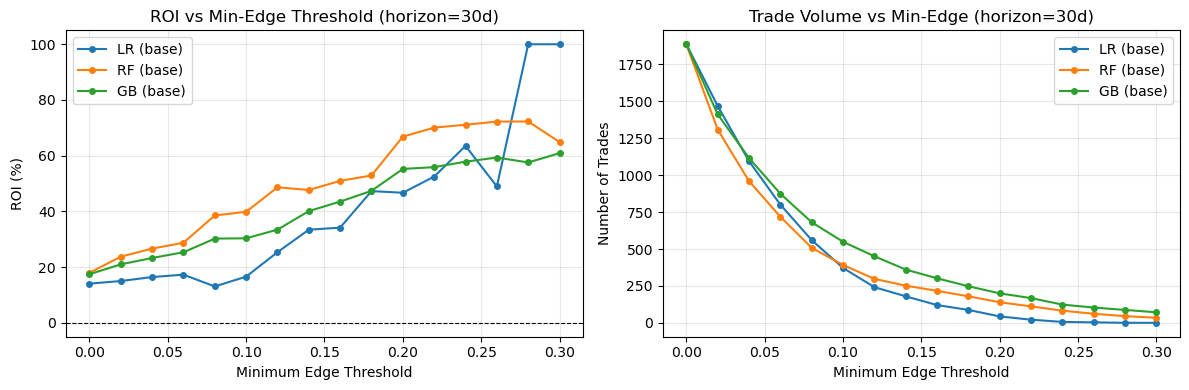

In [12]:
# Fix a representative horizon for edge-sensitivity and category analyses
FIXED_HORIZON = 30

lr_pm = get_horizon_snapshot(lr_merged,      'pred_prob_base',        FIXED_HORIZON)
rf_pm = get_horizon_snapshot(rf_base_merged, 'proba_full_calibrated', FIXED_HORIZON)
gb_pm = get_horizon_snapshot(gb_merged,      'pred_prob_base',        FIXED_HORIZON)

edges = np.arange(0.0, 0.31, 0.02)

focus_models = {
    'LR (base)': (lr_pm, 'model_prob'),
    'RF (base)': (rf_pm, 'model_prob'),
    'GB (base)': (gb_pm, 'model_prob'),
}

edge_results = {name: [] for name in focus_models}
trade_counts = {name: [] for name in focus_models}

for e in edges:
    for name, (pm_df, col) in focus_models.items():
        pnl = simulate_trades(pm_df[col].values, pm_df['market_price'].values,
                              pm_df['outcome'].values, min_edge=e)
        traded = pnl != 0
        cap = pm_df['market_price'].values[traded.values].sum()
        roi = pnl.sum() / cap * 100 if cap > 0 else 0
        edge_results[name].append(roi)
        trade_counts[name].append(traded.sum())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for name, rois in edge_results.items():
    ax1.plot(edges, rois, marker='o', markersize=4, label=name)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xlabel('Minimum Edge Threshold')
ax1.set_ylabel('ROI (%)')
ax1.set_title(f'ROI vs Min-Edge Threshold (horizon={FIXED_HORIZON}d)')
ax1.legend()
ax1.grid(alpha=0.3)

for name, counts in trade_counts.items():
    ax2.plot(edges, counts, marker='o', markersize=4, label=name)
ax2.set_xlabel('Minimum Edge Threshold')
ax2.set_ylabel('Number of Trades')
ax2.set_title(f'Trade Volume vs Min-Edge (horizon={FIXED_HORIZON}d)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('trading_roi_vs_edge.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Cumulative P&L Over Time (LR, RF & GB per-snapshot)

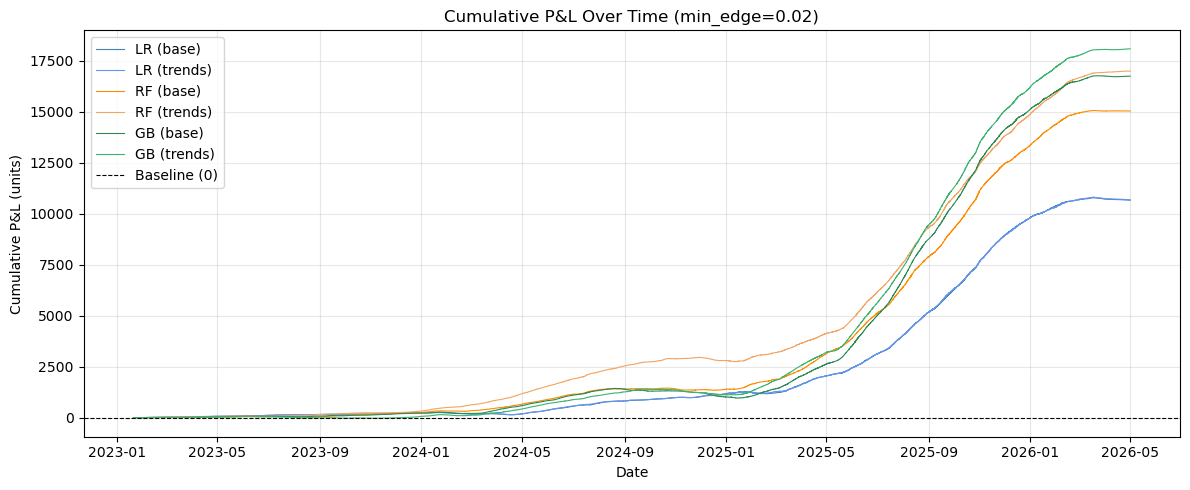

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

sub_lr = lr_merged.dropna(subset=['price_at_snapshot']).copy().sort_values('snapshot_timestamp')
for col, label, color in [
    ('pred_prob_base',   'LR (base)',   'steelblue'),
    ('pred_prob_trends', 'LR (trends)', 'cornflowerblue'),
]:
    pnl = simulate_trades(sub_lr[col].values, sub_lr['price_at_snapshot'].values, sub_lr['outcome'].values)
    ax.plot(sub_lr['snapshot_timestamp'].values, pnl.cumsum().values, label=label, color=color, linewidth=0.8)

sub_rf_base   = rf_base_merged.dropna(subset=['price_at_snapshot']).copy().sort_values('snapshot_timestamp')
sub_rf_trends = rf_merged.dropna(subset=['price_at_snapshot']).copy().sort_values('snapshot_timestamp')
for sub, col, label, color in [
    (sub_rf_base,   'proba_full_calibrated',   'RF (base)',   'darkorange'),
    (sub_rf_trends, 'proba_trends_calibrated',  'RF (trends)', 'sandybrown'),
]:
    pnl = simulate_trades(sub[col].values, sub['price_at_snapshot'].values, sub['outcome'].values)
    ax.plot(sub['snapshot_timestamp'].values, pnl.cumsum().values, label=label, color=color, linewidth=0.8)

sub_gb = gb_merged.dropna(subset=['price_at_snapshot']).copy().sort_values('snapshot_timestamp')
for col, label, color in [
    ('pred_prob_base',   'GB (base)',   'seagreen'),
    ('pred_prob_trends', 'GB (trends)', 'mediumseagreen'),
]:
    pnl = simulate_trades(sub_gb[col].values, sub_gb['price_at_snapshot'].values, sub_gb['outcome'].values)
    ax.plot(sub_gb['snapshot_timestamp'].values, pnl.cumsum().values, label=label, color=color, linewidth=0.8)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='Baseline (0)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative P&L (units)')
ax.set_title(f'Cumulative P&L Over Time (min_edge={MIN_EDGE})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('trading_cumulative_pnl.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. P&L Breakdown by Category

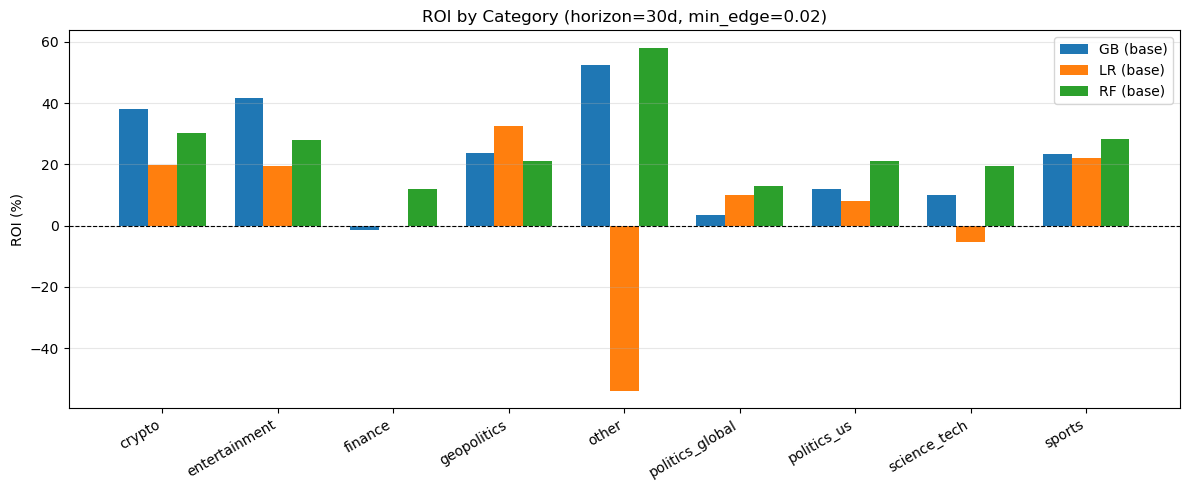

model            GB (base)  LR (base)  RF (base)
category                                        
crypto               38.03      19.87      30.27
entertainment        41.71      19.46      27.85
finance              -1.53       0.06      11.96
geopolitics          23.59      32.67      21.02
other                52.37     -53.94      58.15
politics_global       3.39       9.86      13.11
politics_us          12.01       7.95      21.11
science_tech          9.96      -5.40      19.64
sports               23.43      22.03      28.32


In [14]:
cat_models = [
    (gb_pm, 'GB (base)'),
    (lr_pm, 'LR (base)'),
    (rf_pm, 'RF (base)'),
]

cat_rows = []
for pm_df, label in cat_models:
    pnl = simulate_trades(pm_df['model_prob'].values, pm_df['market_price'].values, pm_df['outcome'].values)
    tmp = pm_df[['category', 'market_price']].copy()
    tmp['pnl'] = pnl.values
    tmp['traded'] = (pnl != 0).values
    grp = tmp[tmp['traded']].groupby('category').agg(
        total_pnl=('pnl', 'sum'),
        n_trades=('pnl', 'count'),
        capital=('market_price', 'sum')
    ).reset_index()
    grp['roi_%'] = grp['total_pnl'] / grp['capital'] * 100
    grp['model'] = label
    cat_rows.append(grp)

cat_df = pd.concat(cat_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 5))
categories = cat_df['category'].unique()
x = np.arange(len(categories))
width = 0.25

for i, (_, label) in enumerate(cat_models):
    vals = [cat_df[(cat_df['model'] == label) & (cat_df['category'] == c)]['roi_%'].values[0]
            if len(cat_df[(cat_df['model'] == label) & (cat_df['category'] == c)]) > 0
            else 0
            for c in categories]
    ax.bar(x + i * width, vals, width, label=label)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x + width)
ax.set_xticklabels(categories, rotation=30, ha='right')
ax.set_ylabel('ROI (%)')
ax.set_title(f'ROI by Category (horizon={FIXED_HORIZON}d, min_edge={MIN_EDGE})')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('trading_roi_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print(cat_df.pivot_table(index='category', columns='model', values='roi_%').round(2))

## 10. Summary Table

In [15]:
print("=" * 60)
print(f"TRADING SIMULATION SUMMARY  (min_edge = {MIN_EDGE})")
print("=" * 60)

print(f"\nHorizon sweep ({HORIZONS.start}–{HORIZONS.stop - 1} days after open):")
print(horizon_df.pivot_table(index='horizon_days', columns='model', values='roi_%').to_string())

print(f"\nPer-snapshot results (LR & RF, note: counts all snapshots as independent trades):")
print(summary_df.to_string(index=False))

print("\nNotes:")
print("  - P&L is in Polymarket token units (1 unit = $1 token).")
print("  - ROI = total_pnl / capital_deployed.")
print(f"  - Horizon simulation: one real trade per market at the snapshot closest to N days after open.")
print(f"  - Edge/category charts use a fixed horizon of {FIXED_HORIZON} days after open.")

TRADING SIMULATION SUMMARY  (min_edge = 0.02)

Horizon sweep (7–90 days after open):
model         GB (base)  GB (trends)  LR (base)  LR (trends)  RF (base)  RF (trends)
horizon_days                                                                        
11                38.26        48.37      11.83        15.09      70.04        29.15
12                21.32        24.54      18.89        17.29      22.94        21.59
13                21.87        25.17      19.92        18.33      23.51        22.43
14                20.90        24.60      18.22        18.53      24.76        21.70
15                20.78        22.63      17.41        16.35      22.04        21.06
16                18.72        21.82      17.08        17.39      22.98        20.31
17                18.85        23.41      18.19        18.12      22.87        19.71
18                17.02        23.23      18.60        17.32      20.52        19.50
19                18.77        22.58      17.86        18.01     